In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import urllib.request
import pandas as pd

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
urllib.request.urlretrieve(url, 'train.csv')

df = pd.read_csv('train.csv')
print("Done! Shape:", df.shape)

Done! Shape: (891, 12)


In [3]:
import pandas as pd
import numpy as np
import urllib.request
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# ── Load data ─────────────────────────────────
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv',
    'train.csv'
)
df = pd.read_csv('train.csv')

# ── Feature engineering ───────────────────────
df['Age']        = df['Age'].fillna(df['Age'].median())
df['Embarked']   = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Sex']        = df['Sex'].map({'female':1, 'male':0})
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['FareBand']   = pd.qcut(
    df['Fare'], 4, labels=[0,1,2,3]).astype(int)
df['Embarked']   = df['Embarked'].map({'S':0,'C':1,'Q':2})

# ── New feature ───────────────────────────────
df['Fare_per_person'] = df['Fare'] / df['FamilySize']

# ── Drop unused columns ───────────────────────
df = df.drop([
    'Cabin','Name','Ticket',
    'PassengerId','SibSp','Parch'
], axis=1)

# ── Split ─────────────────────────────────────
feature_cols = [
    'Pclass','Sex','Age','Fare','Embarked',
    'FamilySize','IsAlone','FareBand',
    'Fare_per_person'
]
X = df[feature_cols]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Train XGBoost tuned ───────────────────────
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

acc = float(accuracy_score(y_test, xgb.predict(X_test)))
print("✅ Everything rebuilt!")
print(f"X_train shape     : {X_train.shape}")
print(f"Features          : {feature_cols}")
print(f"XGBoost accuracy  : {acc:.4f}")


✅ Everything rebuilt!
X_train shape     : (712, 9)
Features          : ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'FareBand', 'Fare_per_person']
XGBoost accuracy  : 0.8156


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(
    max_iter=1000,    # ← increase from default 100
    random_state=42
)
lr.fit(X_train, y_train)
lr_acc = float(accuracy_score(y_test, lr.predict(X_test)))
print(f"LogReg accuracy: {lr_acc:.4f}")


LogReg accuracy: 0.7933


In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest: {rf_acc:.4f}")

Random Forest: 0.8156


In [6]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_acc = accuracy_score(y_test, xgb.predict(X_test))
print(f"XGBoost: {xgb_acc:.4f}")

XGBoost: 0.8045


In [7]:
print("\n--- Model Comparison ---")
print(f"Logistic Regression : {lr_acc:.4f}")
print(f"Random Forest       : {rf_acc:.4f}")
print(f"XGBoost             : {xgb_acc:.4f}")

best_acc = max(lr_acc, rf_acc, xgb_acc)
print(f"\nBest accuracy: {best_acc:.4f}")


--- Model Comparison ---
Logistic Regression : 0.7933
Random Forest       : 0.8156
XGBoost             : 0.8045

Best accuracy: 0.8156


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
import numpy as np

# 1 — define which columns are numeric
num_cols = ['Age', 'Fare', 'Pclass', 'FamilySize']
cat_cols = ['Sex', 'IsAlone', 'FareBand', 'Embarked']

# 2 — preprocessing steps for numeric columns
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 3 — combine numeric + categorical into one preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', SimpleImputer(strategy='most_frequent'), cat_cols)
])

# 4 — full pipeline: preprocessing + model
pipeline = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        n_estimators=100
    ))
])

# 5 — 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline, X, y,
    cv=cv,
    scoring='roc_auc'
)

# 6 — print results
print("CV AUC scores:", np.round(scores, 4))
print(f"Mean AUC : {scores.mean():.4f}")
print(f"Std AUC  : {scores.std():.4f}")
print(f"\nIf Mean AUC > 0.85 → strong model")
print(f"If Std  AUC > 0.03 → unstable, needs tuning")


CV AUC scores: [0.9051 0.8988 0.836  0.8613 0.8813]
Mean AUC : 0.8765
Std AUC  : 0.0253

If Mean AUC > 0.85 → strong model
If Std  AUC > 0.03 → unstable, needs tuning


In [9]:


from xgboost import XGBClassifier
print("XGBoost imported! Version:", __import__('xgboost').__version__)

XGBoost imported! Version: 3.1.3


In [10]:
from xgboost import XGBClassifier
print("Done!")

Done!


In [11]:
# Build and train
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

# Evaluate
from sklearn.metrics import accuracy_score
xgb_acc = accuracy_score(y_test, xgb.predict(X_test))
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

XGBoost Accuracy: 0.8324


In [12]:
print("X_train shape", X_train.shape)
print("X_train shape", X_test.shape)
print("Column:", X_train.columns.tolist())

X_train shape (712, 9)
X_train shape (179, 9)
Column: ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'FareBand', 'Fare_per_person']


In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
print("Training done!")

Training done!


In [14]:
# Predict
y_pred_xgb = xgb.predict(X_test)

# Score
xgb_acc = accuracy_score(y_test, y_pred_xgb)

# Print individually — safe version
print(f"XGBoost Accuracy : {float(xgb_acc):.4f}")

# Only print lr_acc and rf_acc if they exist
try:
    print(f"LogReg Accuracy  : {float(lr_acc):.4f}")
    print(f"Random Forest    : {float(rf_acc):.4f}")
    print(f"\nBest so far      : {float(max(xgb_acc, lr_acc, rf_acc)):.4f}")
except:
    print("Note: lr_acc or rf_acc not found — run those cells first")

XGBoost Accuracy : 0.8045
LogReg Accuracy  : 0.7933
Random Forest    : 0.8156

Best so far      : 0.8156


In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
print("Training done!")

Training done!


In [16]:
# Predict
y_pred_xgb = xgb.predict(X_test)

# Score
xgb_acc = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy : {xgb_acc:.4f}")
print(f"LogReg Accuracy  : {lr_acc:.4f}")
print(f"Random Forest    : {rf_acc:.4f}")
print(f"\nBest so far      : {max(xgb_acc, lr_acc, rf_acc):.4f}")

XGBoost Accuracy : 0.8045
LogReg Accuracy  : 0.7933
Random Forest    : 0.8156

Best so far      : 0.8156


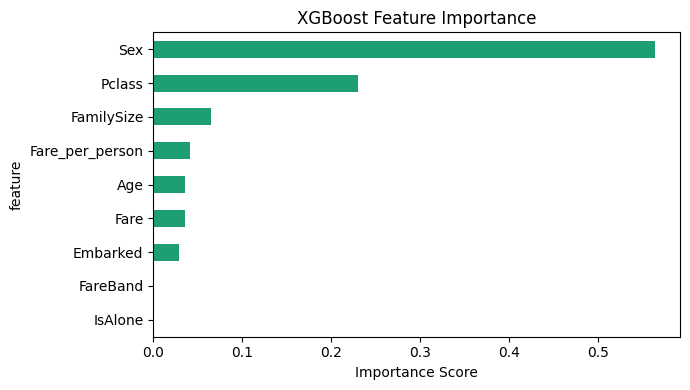

           feature  importance
1              Sex    0.564237
0           Pclass    0.229801
5       FamilySize    0.064870
8  Fare_per_person    0.040754
2              Age    0.036164
3             Fare    0.035673
4         Embarked    0.028501
6          IsAlone    0.000000
7         FareBand    0.000000


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# See which features XGBoost found most useful
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=True)

importance.plot(
    kind='barh',
    x='feature',
    y='importance',
    figsize=(7, 4),
    legend=False,
    color='#1D9E75'
)
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importance.sort_values('importance', ascending=False))

In [18]:
# Tuned params
xgb_tuned = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_tuned.fit(X_train, y_train)
tuned_acc = float(accuracy_score(y_test, xgb_tuned.predict(X_test)))
print(f"Tuned XGBoost     : {tuned_acc:.4f}")

Tuned XGBoost     : 0.8156


In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Your current best
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
xgb_base.fit(X_train, y_train)
base_acc = float(accuracy_score(y_test, xgb_base.predict(X_test)))
print(f"Baseline XGBoost  : {base_acc:.4f}")

Baseline XGBoost  : 0.8045


In [20]:
print("\n" + "="*40)
print("Model Comparison")
print("="*40)
print(f"LogReg             : {lr_acc:.4f}")
print(f"Random Forest      : {rf_acc:.4f}")
print(f"XGBoost default    : {base_acc:.4f}")
print(f"XGBoost tuned      : {tuned_acc:.4f}")
print("="*40)

# Did tuning help?
if tuned_acc > base_acc:
    print(f"Tuning helped by +{(tuned_acc-base_acc):.4f} ")
else:
    print(f"Tuning hurt by {(tuned_acc-base_acc):.4f} ")


Model Comparison
LogReg             : 0.7933
Random Forest      : 0.8156
XGBoost default    : 0.8045
XGBoost tuned      : 0.8156
Tuning helped by +0.0112 


In [21]:
# Fill in your actual scores here
results = {
    'Model':        ['LogReg',       'RF',           'XGB default',  'XGB tuned'],
    'Local Acc':    [lr_acc,         rf_acc,         base_acc,       tuned_acc],
    'CV AUC':       ['',            '?',            '0.8765',       '?'],
    'Kaggle Score': ['0.76555',   '0.74880',   'fill after',   '0.73205'],
    'Notes':        ['baseline',     'best local',   'default params','n300 depth5 lr0.05']
}

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

      Model  Local Acc CV AUC Kaggle Score              Notes
     LogReg   0.793296             0.76555           baseline
         RF   0.815642      ?      0.74880         best local
XGB default   0.804469 0.8765   fill after     default params
  XGB tuned   0.815642      ?      0.73205 n300 depth5 lr0.05


In [22]:

lr_kaggle   = 0.76555  
rf_kaggle   = 0.74880   
xgb_kaggle  = 0.68181 
tuned_kaggle= 0.73205   
print()
print("="*65)
print(f"{'Model':<20} {'Local':>8} {'CV AUC':>8} {'Kaggle':>8}  Notes")
print("="*65)
print(f"{'LogReg':<20} {lr_acc:>8.4f} {'—':>8} {lr_kaggle:>8.4f}  baseline")
print(f"{'Random Forest':<20} {rf_acc:>8.4f} {'—':>8} {rf_kaggle:>8.4f}  100 trees")
print(f"{'XGB default':<20} {base_acc:>8.4f} {'0.8765':>8} {xgb_kaggle:>8.4f}  default params")
print(f"{'XGB tuned':<20} {tuned_acc:>8.4f} {'?':>8} {tuned_kaggle:>8.4f}  n300 d5 lr0.05")
print("="*65)

best_kaggle = max(lr_kaggle, rf_kaggle, xgb_kaggle, tuned_kaggle)
print(f"\nBest Kaggle score so far: {best_kaggle:.4f}")

if best_kaggle > 0.79:
    print("Beating Day 3 baseline ✅")
else:
    print("Not beating baseline yet ❌ — check CV gap")


Model                   Local   CV AUC   Kaggle  Notes
LogReg                 0.7933        —   0.7655  baseline
Random Forest          0.8156        —   0.7488  100 trees
XGB default            0.8045   0.8765   0.6818  default params
XGB tuned              0.8156        ?   0.7320  n300 d5 lr0.05

Best Kaggle score so far: 0.7655
Not beating baseline yet ❌ — check CV gap


In [23]:
import os
print (os.listdir('/kaggle/working/'))

['.virtual_documents', 'train.csv']


In [24]:
# ── Add Fare_per_person to train ──────────────
df['Fare_per_person'] = df['Fare'] / df['FamilySize']

# Verify
print(df[['Fare', 'FamilySize', 'Fare_per_person']].head(10))
print("\nFare_per_person stats:")
print(df['Fare_per_person'].describe().round(2))

      Fare  FamilySize  Fare_per_person
0   7.2500           2          3.62500
1  71.2833           2         35.64165
2   7.9250           1          7.92500
3  53.1000           2         26.55000
4   8.0500           1          8.05000
5   8.4583           1          8.45830
6  51.8625           1         51.86250
7  21.0750           5          4.21500
8  11.1333           3          3.71110
9  30.0708           2         15.03540

Fare_per_person stats:
count    891.00
mean      19.92
std       35.84
min        0.00
25%        7.25
50%        8.30
75%       23.67
max      512.33
Name: Fare_per_person, dtype: float64


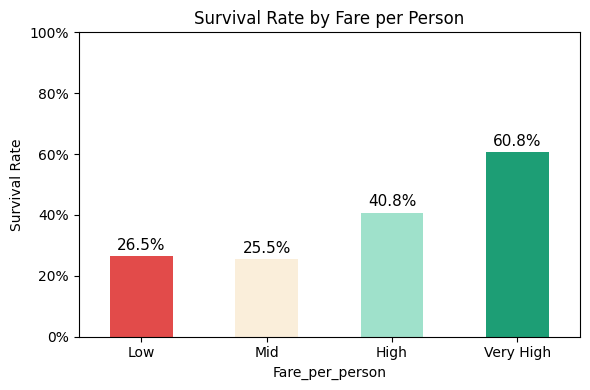

Fare_per_person
Low         0.265
Mid         0.255
High        0.408
VeryHigh    0.608
Name: Survived, dtype: float64


In [25]:
import matplotlib.pyplot as plt

survival_by_fpp = df.groupby(
    pd.qcut(df['Fare_per_person'], 4,
            labels=['Low','Mid','High','VeryHigh']),
    observed=True
)['Survived'].mean()

ax = survival_by_fpp.plot(
    kind='bar',
    color=['#E24B4A','#FAEEDA','#9FE1CB','#1D9E75'],
    figsize=(6,4), edgecolor='none'
)
ax.set_title('Survival Rate by Fare per Person')
ax.set_ylabel('Survival Rate')
ax.set_xticklabels(
    ['Low','Mid','High','Very High'], rotation=0)
ax.set_ylim(0,1)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y,_: f'{y:.0%}'))
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',
        (p.get_x()+p.get_width()/2,
         p.get_height()+0.01),
        ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

print(survival_by_fpp.round(3))

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Without new feature
X_old = df[['Pclass','Sex','Age','Fare','Embarked',
            'FamilySize','IsAlone','FareBand']]
y = df['Survived']

X_tr_old, X_te_old, y_tr, y_te = train_test_split(
    X_old, y, test_size=0.2, random_state=42)

xgb_old = XGBClassifier(
    n_estimators=300, max_depth=5,
    learning_rate=0.05, subsample=0.8,
    random_state=42, eval_metric='logloss')
xgb_old.fit(X_tr_old, y_tr)
acc_old = float(accuracy_score(
    y_te, xgb_old.predict(X_te_old)))

# With new feature
X_new = df[['Pclass','Sex','Age','Fare','Embarked',
            'FamilySize','IsAlone','FareBand',
            'Fare_per_person']]   # ← added

X_tr_new, X_te_new, _, _ = train_test_split(
    X_new, y, test_size=0.2, random_state=42)

xgb_new = XGBClassifier(
    n_estimators=300, max_depth=5,
    learning_rate=0.05, subsample=0.8,
    random_state=42, eval_metric='logloss')
xgb_new.fit(X_tr_new, y_tr)
acc_new = float(accuracy_score(
    y_te, xgb_new.predict(X_te_new)))

# Result
print("="*40)
print(f"Without Fare_per_person: {acc_old:.4f}")
print(f"With    Fare_per_person: {acc_new:.4f}")
print(f"Difference             : {acc_new-acc_old:+.4f}")
print("="*40)

if acc_new > acc_old:
    print("✅ Feature helps — keep it")
elif acc_new == acc_old:
    print("➡ No change — optional")
else:
    print("❌ Feature hurts — drop it")

Without Fare_per_person: 0.8045
With    Fare_per_person: 0.8156
Difference             : +0.0112
✅ Feature helps — keep it
